✅ Modelo R5K v3 entrenado y unificado.
📊 Precisión: 0.9720


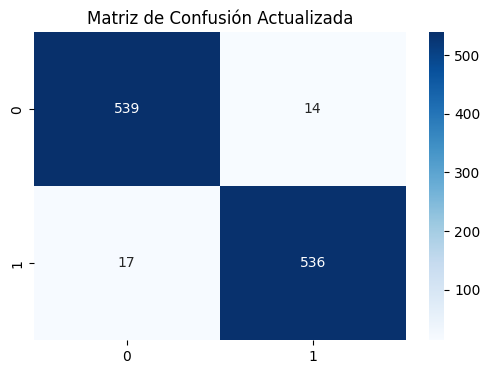

✨ Archivo unificado guardado en Drive: R5K_v3.pk1


/tmp/ipython-input-1314084010.py:108: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f13498e636d0da4f34.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [20]:
# =================================================================
# PROYECTO: MOTOR DE IA R5K V3 - VERSIÓN UNIFICADA PARA BACKEND
# =================================================================

import pandas as pd
import numpy as np
import os
import joblib
import nltk
import gradio as gr
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. CONEXIÓN A DRIVE
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words_mix = list(set(stopwords.words('spanish') + stopwords.words('portuguese')))

# RUTAS UNIFICADAS
CARPETA_TRABAJO = "/content/drive/MyDrive/Colab Notebooks/hackathon/Ultimo modelo multilenguaje/"
RUTA_BASE = os.path.join(CARPETA_TRABAJO, "dataset_modelado_sentimiento.csv")
RUTA_FEEDBACK = os.path.join(CARPETA_TRABAJO, "consultas_recolectadas.csv")
# ÚNICO ARCHIVO REQUERIDO POR BACKEND
RUTA_ROBOT_UNICO = os.path.join(CARPETA_TRABAJO, "R5K_v3.pk1")

def cargar_y_entrenar_sistema():
    plt.close('all')
    dfs_entrenamiento = []

    if os.path.exists(RUTA_BASE):
        df_base = pd.read_csv(RUTA_BASE)
        df_base.columns = df_base.columns.str.lower()
        df_base = df_base.rename(columns={'y': 'label', 'clean_text': 'text_clean'})
        dfs_entrenamiento.append(df_base[['text_clean', 'label']])

    if os.path.exists(RUTA_FEEDBACK):
        df_feedback = pd.read_csv(RUTA_FEEDBACK)
        df_feedback.columns = df_feedback.columns.str.lower()
        df_feedback = df_feedback.rename(columns={'y': 'label', 'clean_text': 'text_clean'})
        if not df_feedback.empty:
            dfs_entrenamiento.append(df_feedback[['text_clean', 'label']])

    df_total = pd.concat(dfs_entrenamiento, ignore_index=True).dropna(subset=['text_clean', 'label'])

    # Limpieza y Balanceo
    conteo = df_total.groupby('text_clean')['label'].nunique()
    df_total = df_total[~df_total['text_clean'].isin(conteo[conteo > 1].index)]

    df_0 = df_total[df_total['label'] == 0]
    df_1 = df_total[df_total['label'] == 1]
    target = min(len(df_0), len(df_1))
    df_balanced = pd.concat([df_0.sample(n=target, random_state=42),
                             df_1.sample(n=target, random_state=42)]).sample(frac=1, random_state=42)

    X = df_balanced['text_clean'].astype(str)
    y = df_balanced['label'].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    # PIPELINE UNIFICADO (Contiene Vectorizador + Clasificador)
    pipeline_v2 = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 3), stop_words=stop_words_mix, sublinear_tf=True)),
        ("clf", LogisticRegression(C=1.5, class_weight="balanced", max_iter=1000))
    ])
    pipeline_v2.fit(X_train, y_train)

    # VISUALIZACIÓN
    clear_output(wait=True)
    y_pred = pipeline_v2.predict(X_test)
    print(f"✅ Modelo R5K v3 entrenado y unificado.")
    print(f"📊 Precisión: {accuracy_score(y_test, y_pred):.4f}")

    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title("Matriz de Confusión Actualizada")
    plt.show()

    # GUARDADO ÚNICO
    joblib.dump(pipeline_v2, RUTA_ROBOT_UNICO)
    print(f"✨ Archivo unificado guardado en Drive: R5K_v3.pk1")

    return pipeline_v2

# Inicializar
pipeline = cargar_y_entrenar_sistema()

# Interfaz Gradio (sin cambios en la lógica)
def procesar_interfaz(texto, correccion=None):
    global pipeline
    if correccion:
        nueva_fila = pd.DataFrame({'clean_text': [texto], 'y': [1 if correccion=="POS" else 0]})
        nueva_fila.to_csv(RUTA_FEEDBACK, mode='a', header=False, index=False)
        pipeline = cargar_y_entrenar_sistema()
        return "✅ Robot actualizado en Drive", 1.0
    prob = pipeline.predict_proba([texto])[0]
    pred = pipeline.predict([texto])[0]
    return "POSITIVO" if pred == 1 else "NEGATIVO", round(float(prob[pred]), 2)

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🤖 R5K v3 - Versión Final Unificada")
    with gr.Row():
        entrada = gr.Textbox(label="Texto")
        resultado = gr.Label(label="Resultado")
        seguridad = gr.Number(label="Confianza")
    btn = gr.Button("Analizar", variant="primary")
    btn.click(procesar_interfaz, inputs=[entrada], outputs=[resultado, seguridad])
    with gr.Row():
        gr.Button("Es POSITIVO ✅").click(fn=lambda t: procesar_interfaz(t, "POS"), inputs=[entrada], outputs=[resultado, seguridad])
        gr.Button("Es NEGATIVO ❌").click(fn=lambda t: procesar_interfaz(t, "NEG"), inputs=[entrada], outputs=[resultado, seguridad])

demo.launch()

In [21]:
contenido_req = """pandas==2.1.4
numpy==1.26.2
scikit-learn==1.3.2
joblib==1.3.2
nltk==3.8.1
gradio==4.12.0
matplotlib==3.7.1
seaborn==0.12.2"""

with open('/content/drive/MyDrive/Colab Notebooks/hackathon/Ultimo modelo multilenguaje/requirements.txt', 'w') as f:
    f.write(contenido_req)
print("✅ Archivo requirements.txt creado en Drive")

✅ Archivo requirements.txt creado en Drive
